# CNNs for Text Classification
En esta práctica vamos a ver cómo se pueden utilizar las Convolutional Neural Networks (CNNs) para text classification haciendo uso de word embedding pre-entrenados.

El dataset que vamos a usar es el de [AG-News](https://huggingface.co/datasets/ag_news?row=20). AG-News contiene alrededor de 150,000 noticias anotadas en cuatro categorias diferentes: World (0), Sports (1), Business (2), Sci/Tech (3).

Sin embargo, como hemos hecho en anteriores prácticas vamos a trabajar con un subset de este dataset, el **subset** podéis **descargarlo** de [**aqui**](https://drive.google.com/file/d/1MGZASiQg94v31gMw2It_MngrpXA9iyNo/view?usp=sharing).

Todo el código está basado en el libro de *Rao, D., & McMahan, B. (2019). Natural language processing with PyTorch: build intelligent language applications using deep learning.*

In [ ]:
!pip install torch
!pip install torchinfo
!pip install gensim
!pip install transformers


Creamos la carpeta *model_storage* donde iremos guardando los mejores modelos, comparando el rendimiento del modelo en cada epoch.

In [ ]:
!mkdir model_storage

Importamos todas las librerias necesarias. Aparte de las típicas librerias para tratar datos y PyTorch, vamos a utilizar estas dos otras librerias:


*   **tqdm**: para visualizar el estado de cada uno de los epochs.
*   **torchinfo**: para visualizar el modelo que vayamos a crear de una manera más descriptiva.





In [ ]:
import os
from argparse import Namespace
from collections import Counter
import json
import re
import string

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import tqdm
from tqdm import tqdm_notebook
from torchinfo import summary

## Vocabulary

Es practicamente la misma clase que usamos con el perceptron. Sin embargo, vamos a extender su utilidad usando herencia.

In [ ]:
class Vocabulary(object):
    """Clase para procesar texto y extrar el vocabulario existente para su posterior mapeo."""

    def __init__(self, token_to_idx=None):
        """
        Args:
            token_to_idx (dict): a pre-existing map of tokens to indices
        """

        if token_to_idx is None:
            token_to_idx = {}
        self._token_to_idx = token_to_idx

        self._idx_to_token = {idx: token
                              for token, idx in self._token_to_idx.items()}

    def to_serializable(self):
        """ returns a dictionary that can be serialized """
        return {'token_to_idx': self._token_to_idx}

    @classmethod
    def from_serializable(cls, contents):
        """ instantiates the Vocabulary from a serialized dictionary """
        return cls(**contents)

    def add_token(self, token):
        """Update mapping dicts based on the token.

        Args:
            token (str): the item to add into the Vocabulary
        Returns:
            index (int): the integer corresponding to the token
        """
        if token in self._token_to_idx:
            index = self._token_to_idx[token]
        else:
            index = len(self._token_to_idx)
            self._token_to_idx[token] = index
            self._idx_to_token[index] = token
        return index

    def add_many(self, tokens):
        """Add a list of tokens into the Vocabulary

        Args:
            tokens (list): a list of string tokens
        Returns:
            indices (list): a list of indices corresponding to the tokens
        """
        return [self.add_token(token) for token in tokens]

    def lookup_token(self, token):
        """Retrieve the index associated with the token

        Args:
            token (str): the token to look up
        Returns:
            index (int): the index corresponding to the token
        """
        return self._token_to_idx[token]

    def lookup_index(self, index):
        """Return the token associated with the index

        Args:
            index (int): the index to look up
        Returns:
            token (str): the token corresponding to the index
        Raises:
            KeyError: if the index is not in the Vocabulary
        """
        if index not in self._idx_to_token:
            raise KeyError("the index (%d) is not in the Vocabulary" % index)
        return self._idx_to_token[index]

    def __str__(self):
        return "<Vocabulary(size=%d)>" % len(self)

    def __len__(self):
        return len(self._token_to_idx)

La clase vocabulario que hemos estado usando hasta ahora no es suficiente por sí sola. Al empezar a usar la secuencialidad de las palabras dentro de las oraciones y frases debemos de empezar a usar unos tokens.

**\<UNK\>**: token que se usa para reemplazar aquellas palabras que no están en nuestro vocabulario.  
**\<MASK\>**: token que se usa para paddear la frase u oración hasta la máxima longitud permitida.  
**\<BEGIN\>**: se utiliza para indicar el inicio de una oración.       
**\<END\>**: se utiliza para indicar el final de una oración y el inicio en la mayoría de casos del padding.

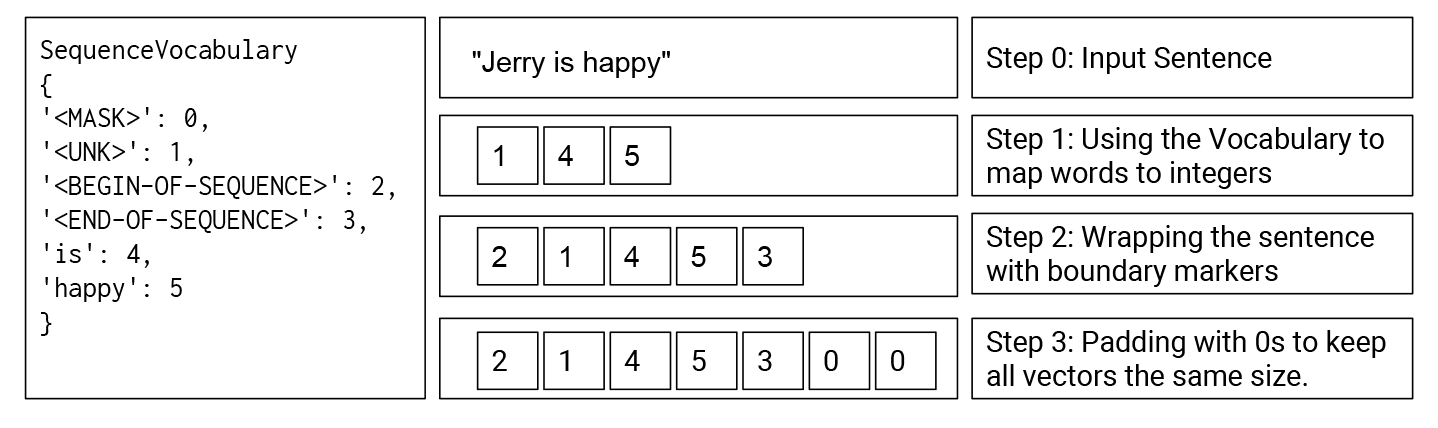



In [ ]:
class SequenceVocabulary(Vocabulary):
    """Extensión de la clase vocabulario para lidiar con la secuencialidad del texto."""
    def __init__(self, token_to_idx=None, unk_token="<UNK>",
                 mask_token="<MASK>", begin_seq_token="<BEGIN>",
                 end_seq_token="<END>"):

        super(SequenceVocabulary, self).__init__(token_to_idx) #Llamamos al constructor padre.

        self._mask_token = mask_token
        self._unk_token = unk_token
        self._begin_seq_token = begin_seq_token
        self._end_seq_token = end_seq_token

        #Usamos el vocabulario inicial y añadimos los nuevos tokens de uso especial.
        self.mask_index = self.add_token(self._mask_token) #Padding
        self.unk_index = self.add_token(self._unk_token) #Tokens desconocidos
        self.begin_seq_index = self.add_token(self._begin_seq_token) #Inicio de una frase.
        self.end_seq_index = self.add_token(self._end_seq_token) #Fin de una frase.

    def to_serializable(self):
        contents = super(SequenceVocabulary, self).to_serializable()
        contents.update({'unk_token': self._unk_token,
                         'mask_token': self._mask_token,
                         'begin_seq_token': self._begin_seq_token,
                         'end_seq_token': self._end_seq_token})
        return contents

    def lookup_token(self, token):
        """Retrieve the index associated with the token
          or the UNK index if token isn't present.

        Args:
            token (str): the token to look up
        Returns:
            index (int): the index corresponding to the token
        Notes:
            `unk_index` needs to be >=0 (having been added into the Vocabulary)
              for the UNK functionality
        """
        if self.unk_index >= 0:
            return self._token_to_idx.get(token, self.unk_index)
        else:
            return self._token_to_idx[token]

## NewsVectorizer

El vectorizer sigue teniendo el mismo propósito que el anterior pero vamos a representar el texto de una forma diferente.

En el vectorizer que usamos en la anterior práctica, repesentabamos cada oración en un vector de longitud igual al número de tokens únicos.

Por ejemplo:

  

> **Vocab**: `{"UNK": 0, "hola": 1, "me": 2, "llamo": 3, "ernesto": 4, "joaquin": 5, "llaman":6}`


> Frase de **origen**: `"Hola me llaman Joaquín"`


>  Frase en **one_hot_encoding**: `[0, 1, 1, 0, 0, 1, 1]`


Sin embargo, este vectorizer debería transformar esa misma frase a la siguiente representación (asumiendo que la **longitud máxima** de una frase son **10 tokens**).


> **Vocab**: `{"UNK": 0, "hola": 1, "me": 2, "llamo": 3, "ernesto": 4, "joaquin": 5, "llaman":6, "MASK": 7, "BEGIN": 8, "END": 9}`

>  Frase con **nueva representación**: `[8, 1, 2, 6, 5, 9, 7, 7, 7, 7]`


**Ejercicio 1:** Analiza la clase Vectorizer (dónde se añade el token de inicio, final, etc.) e implementa el padding hacia la derecha hasta llegar a la longitud máxima. Para ello, primeros tienes que identificar cómo se calcula la longitud máxima.

In [ ]:
class NewsVectorizer(object):
    """ Usando el vocabulario, transforma cada token a su ID numérico y añade los tokens auxiliares necesarios (MASK, BEGIN, END...)"""
    def __init__(self, title_vocab, category_vocab):
        self.title_vocab = title_vocab #Vocabulario de todos los tokens que usamos.
        self.category_vocab = category_vocab #Vocabulario que representa las 4 categorias a las que estamos clasificando las noticias.

    def vectorize(self, title, vector_length=-1):
        """
        Args:
            title (str): the string of words separated by a space
            vector_length (int): an argument for forcing the length of index vector
        Returns:
            the vetorized title (numpy.array)
        """
        indices = [self.title_vocab.begin_seq_index]
        indices.extend(self.title_vocab.lookup_token(token)
                       for token in title.split(" "))
        indices.append(self.title_vocab.end_seq_index)

        if vector_length < 0:
            vector_length = len(indices)

        #Todo 0s con longitud maxima
        out_vector = np.zeros(vector_length, dtype=np.int64)
        out_vector[:len(indices)] = indices
        out_vector[len(indices):] = self.title_vocab.mask_index

        return out_vector

    @classmethod
    def from_dataframe(cls, news_df, cutoff=5):
        """Instantiate the vectorizer from the dataset dataframe

        Args:
            news_df (pandas.DataFrame): the target dataset
            cutoff (int): frequency threshold for including in Vocabulary
        Returns:
            an instance of the NewsVectorizer
        """
        category_vocab = Vocabulary()
        for category in sorted(set(news_df.category)):
            category_vocab.add_token(category)

        word_counts = Counter()
        for title in news_df.title:
            for token in title.split(" "):
                if token not in string.punctuation:
                    word_counts[token] += 1

        title_vocab = SequenceVocabulary()
        for word, word_count in word_counts.items():
            if word_count >= cutoff:
                title_vocab.add_token(word)

        return cls(title_vocab, category_vocab)

    @classmethod
    def from_serializable(cls, contents):
        title_vocab = \
            SequenceVocabulary.from_serializable(contents['title_vocab'])
        category_vocab =  \
            Vocabulary.from_serializable(contents['category_vocab'])

        return cls(title_vocab=title_vocab, category_vocab=category_vocab)

    def to_serializable(self):
        return {'title_vocab': self.title_vocab.to_serializable(),
                'category_vocab': self.category_vocab.to_serializable()}

def generate_batches(dataset, batch_size, shuffle=True,
                     drop_last=True, device="cpu"):
    """
    A generator function which wraps the PyTorch DataLoader. It will
      ensure each tensor is on the write device location.
    """
    dataloader = DataLoader(dataset=dataset, batch_size=batch_size,
                            shuffle=shuffle, drop_last=drop_last)

    for data_dict in dataloader:
        out_data_dict = {}
        for name, tensor in data_dict.items():
            out_data_dict[name] = data_dict[name].to(device)
        yield out_data_dict

In [ ]:
class NewsDataset(Dataset):
    def __init__(self, news_df, vectorizer):
        """
        Args:
            news_df (pandas.DataFrame): the dataset
            vectorizer (NewsVectorizer): vectorizer instatiated from dataset
        """
        self.news_df = news_df
        self._vectorizer = vectorizer

        # +1 if only using begin_seq, +2 if using both begin and end seq tokens
        measure_len = lambda context: len(context.split(" "))
        self._max_seq_length = max(map(measure_len, news_df.title)) + 2


        self.train_df = self.news_df[self.news_df.split=='train']
        self.train_size = len(self.train_df)

        self.val_df = self.news_df[self.news_df.split=='val']
        self.validation_size = len(self.val_df)

        self.test_df = self.news_df[self.news_df.split=='test']
        self.test_size = len(self.test_df)

        self._lookup_dict = {'train': (self.train_df, self.train_size),
                             'val': (self.val_df, self.validation_size),
                             'test': (self.test_df, self.test_size)}

        self.set_split('train')

        # Class weights
        class_counts = news_df.category.value_counts().to_dict()
        def sort_key(item):
            return self._vectorizer.category_vocab.lookup_token(item[0])
        sorted_counts = sorted(class_counts.items(), key=sort_key)
        frequencies = [count for _, count in sorted_counts]
        self.class_weights = 1.0 / torch.tensor(frequencies, dtype=torch.float32)


    @classmethod
    def load_dataset_and_make_vectorizer(cls, news_csv):
        """Load dataset and make a new vectorizer from scratch

        Args:
            surname_csv (str): location of the dataset
        Returns:
            an instance of SurnameDataset
        """
        news_df = pd.read_csv(news_csv)
        train_news_df = news_df[news_df.split=='train']
        return cls(news_df, NewsVectorizer.from_dataframe(train_news_df))

    @classmethod
    def load_dataset_and_load_vectorizer(cls, news_csv, vectorizer_filepath):
        """Load dataset and the corresponding vectorizer.
        Used in the case in the vectorizer has been cached for re-use

        Args:
            surname_csv (str): location of the dataset
            vectorizer_filepath (str): location of the saved vectorizer
        Returns:
            an instance of SurnameDataset
        """
        news_df = pd.read_csv(news_csv)
        vectorizer = cls.load_vectorizer_only(vectorizer_filepath)
        return cls(news_csv, vectorizer)

    @staticmethod
    def load_vectorizer_only(vectorizer_filepath):
        """a static method for loading the vectorizer from file

        Args:
            vectorizer_filepath (str): the location of the serialized vectorizer
        Returns:
            an instance of NewsVectorizer
        """
        with open(vectorizer_filepath) as fp:
            return NewsVectorizer.from_serializable(json.load(fp))

    def save_vectorizer(self, vectorizer_filepath):
        """saves the vectorizer to disk using json

        Args:
            vectorizer_filepath (str): the location to save the vectorizer
        """
        with open(vectorizer_filepath, "w") as fp:
            json.dump(self._vectorizer.to_serializable(), fp)

    def get_vectorizer(self):
        """ returns the vectorizer """
        return self._vectorizer

    def set_split(self, split="train"):
        """ selects the splits in the dataset using a column in the dataframe """
        self._target_split = split
        self._target_df, self._target_size = self._lookup_dict[split]

    def __len__(self):
        return self._target_size

    def __getitem__(self, index):
        """the primary entry point method for PyTorch datasets

        Args:
            index (int): the index to the data point
        Returns:
            a dictionary holding the data point's features (x_data) and label (y_target)
        """
        row = self._target_df.iloc[index]

        title_vector = \
            self._vectorizer.vectorize(row.title, self._max_seq_length)

        category_index = \
            self._vectorizer.category_vocab.lookup_token(row.category)

        return {'x_data': title_vector,
                'y_target': category_index}

    def get_num_batches(self, batch_size):
        """Given a batch size, return the number of batches in the dataset

        Args:
            batch_size (int)
        Returns:
            number of batches in the dataset
        """
        return len(self) // batch_size

def generate_batches(dataset, batch_size, shuffle=True,
                     drop_last=True, device="cpu"):
    """
    A generator function which wraps the PyTorch DataLoader. It will
      ensure each tensor is on the write device location.
    """
    dataloader = DataLoader(dataset=dataset, batch_size=batch_size,
                            shuffle=shuffle, drop_last=drop_last)

    for data_dict in dataloader:
        out_data_dict = {}
        for name, tensor in data_dict.items():
            out_data_dict[name] = data_dict[name].to(device)
        yield out_data_dict

## Early stopping y model checkpoints

Durante entrenamiento de este modelo de CNNs para la clasificación de texto vamos usar dos técnicas que hemos comentado en casa:

*   **Early stopping**: técnica de regularización utilizada para evitar el sobreajuste del modelo durante el entrenamiento. Durante el proceso de entrenamiento, no solo vamos a monitorizar el desempeño del modelo en el conjunto de entrenamiento, sino también en el cojunto de evaluación.
La idea detrás del *"early stopping*" es detener el entrenamiento en el momento en que el rendimiento en el conjunto de evaluación empiece a empeorar o no mejore durante un número específico de epochs.


*   **Model checkpoints**: cada vez que haya una mejora en el loss de eval, guardamos el estado del modelo en ese epoch. También podemos usar el accuracy, el recall, precision o F1 como métricas de referencia además del loss. Siempre en base a EVAL.

**Ejercicio 2:** Analiza el siguiente código y responde a las siguientes preguntas:
*   ¿Cuántos epochs sin que el modelo mejore necesita el early stopping para actuar?
*   ¿Cuándo se va a guardar el modelo?




In [ ]:
def make_train_state(args):
    return {'stop_early': False,
            'early_stopping_step': 0,
            'early_stopping_best_val': 1e8,
            'learning_rate': args.learning_rate,
            'epoch_index': 0,
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'test_loss': -1,
            'test_acc': -1,
            'model_filename': args.model_state_file}

def update_train_state(args, model, train_state):
    """Handle the training state updates.

    Components:
     - Early Stopping: Prevent overfitting.
     - Model Checkpoint: Model is saved if the model is better

    :param args: main arguments
    :param model: model to train
    :param train_state: a dictionary representing the training state values
    :returns:
        a new train_state
    """

    if train_state['epoch_index'] == 0:
        torch.save(model.state_dict(), train_state['model_filename'])
        train_state['stop_early'] = False

    elif train_state['epoch_index'] >= 1:
        loss_tm1, loss_t = train_state['val_loss'][-2:]

        if loss_t >= train_state['early_stopping_best_val']:
            # Update step
            train_state['early_stopping_step'] += 1
        else:
            if loss_t < train_state['early_stopping_best_val']:
                torch.save(model.state_dict(), train_state['model_filename'])
                train_state['early_stopping_best_val'] = loss_t


            train_state['early_stopping_step'] = 0

        # Stop early ?
        train_state['stop_early'] = \
            train_state['early_stopping_step'] >= args.early_stopping_criteria

    return train_state

def compute_accuracy(y_pred, y_target):
    _, y_pred_indices = y_pred.max(dim=1)
    n_correct = torch.eq(y_pred_indices, y_target).sum().item()
    return n_correct / len(y_pred_indices) * 100

## Convolutional Neural Networks para texto (CNNs)



A la hora de usar CNNs en combinación con texto podemos usar diferentes arquitecturas de CNNs (tamaños de los filtros, nested CNNs, diferentes valores de stride, etc.).

**Primero** vamos a implementar la siguiente arquitectura donde vamos encadenando Conv1Ds de tamaño 3 que vamos reduciendo a traves del uso del stride.

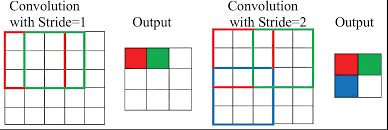

En este caso vamos a usar ELU en lugar de RELU, ambas buscan introducir no-linearidad a la red:



*   **ReLU**: Anula completamente los valores negativos, lo que significa que la salida para cualquier entrada negativa es 0.

*   **ELU**: Proporciona una salida saturada suave para valores negativos, es decir, no es exactamente 0 sino un valor negativo basado en la exponenciación.


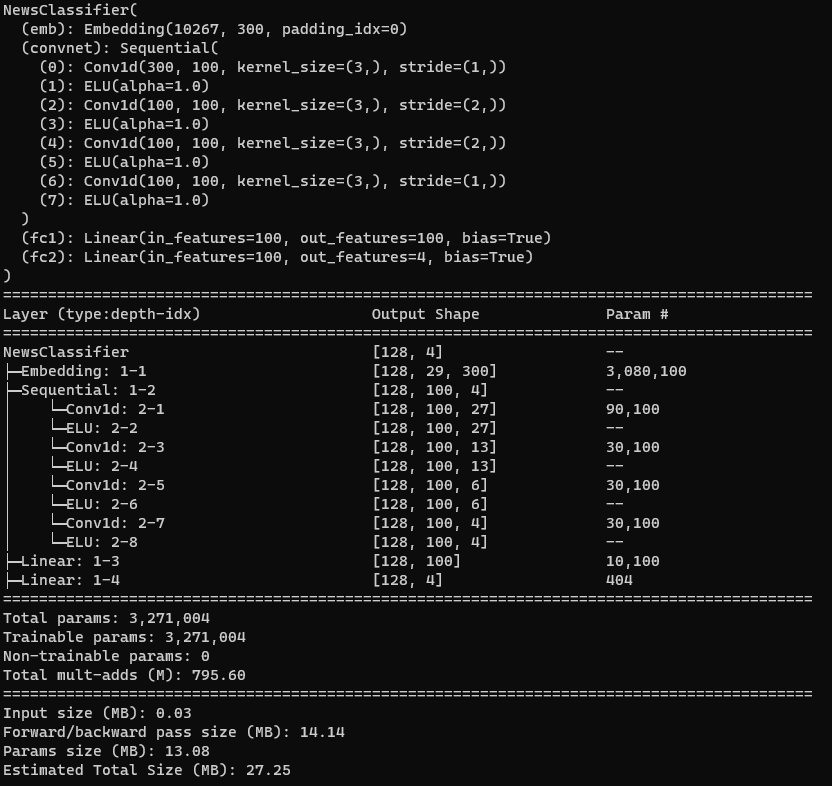








In [ ]:
class NewsClassifier(nn.Module):
    def __init__(self, embedding_size, num_embeddings, num_channels,
                 hidden_dim, num_classes, dropout_p,
                 pretrained_embeddings=None, padding_idx=0):
        """
        Args:
            embedding_size (int): size of the embedding vectors
            num_embeddings (int): number of embedding vectors
            filter_width (int): width of the convolutional kernels
            num_channels (int): number of convolutional kernels per layer
            hidden_dim (int): the size of the hidden dimension
            num_classes (int): the number of classes in classification
            dropout_p (float): a dropout parameter
            pretrained_embeddings (numpy.array): previously trained word embeddings
                default is None. If provided,
            padding_idx (int): an index representing a null position
        """
        super(NewsClassifier, self).__init__()

        if pretrained_embeddings is None:
            #En caso de no usar embeddings pre-entrenados, se inicializan usando una distribución normal con media 0 y desviación estándar 1.
            self.emb = nn.Embedding(embedding_dim=embedding_size,
                                    num_embeddings=num_embeddings,
                                    padding_idx=padding_idx)
        else:
            #Usamos embvddings pre-entrenados.
            pretrained_embeddings = torch.from_numpy(pretrained_embeddings).float()
            self.emb = nn.Embedding(embedding_dim=embedding_size,
                                    num_embeddings=num_embeddings,
                                    padding_idx=padding_idx,
                                    _weight=pretrained_embeddings)


        self.convnet = nn.Sequential(
            nn.Conv1d(in_channels=embedding_size,
                   out_channels=num_channels, kernel_size=3),
            nn.ELU(),
            nn.Conv1d(in_channels=num_channels, out_channels=num_channels,
                   kernel_size=3, stride=2),
            nn.ELU(),
            nn.Conv1d(in_channels=num_channels, out_channels=num_channels,
                   kernel_size=3, stride=2),
            nn.ELU(),
            nn.Conv1d(in_channels=num_channels, out_channels=num_channels,
                   kernel_size=3),
            nn.ELU()
        )

        self._dropout_p = dropout_p
        self.fc1 = nn.Linear(num_channels, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x_in, apply_softmax=False):
        """The forward pass of the classifier

        Args:
            x_in (torch.Tensor): an input data tensor.
                x_in.shape should be (batch, dataset._max_seq_length)
            apply_softmax (bool): a flag for the softmax activation
                should be false if used with the Cross Entropy losses
        Returns:
            the resulting tensor. tensor.shape should be (batch, num_classes)
        """

        # self.emb(x_in) transforma el indice de cada una de las 29 palabras a su correspondiendo word embedding --> (batch_size, sequence_length, embedding_dim).
        # Despues permutamos de (batch_size, sequence_length, embedding_dim) a (batch_size, embedding_dim, sequence_length) por cómo espera la CONV1D los datos.
        x_embedded = self.emb(x_in).permute(0, 2, 1)

        features = self.convnet(x_embedded)

        # average and remove the extra dimension
        remaining_size = features.size(dim=2)
        features = F.avg_pool1d(features, remaining_size).squeeze(dim=2)
        features = F.dropout(features, p=self._dropout_p)

        # mlp classifier
        intermediate_vector = F.relu(F.dropout(self.fc1(features), p=self._dropout_p))
        prediction_vector = self.fc2(intermediate_vector)

        if apply_softmax:
            prediction_vector = F.softmax(prediction_vector, dim=1)

        return prediction_vector



Después, vamos a utilizar la siguiente configuración de CNNs for Text Classification:

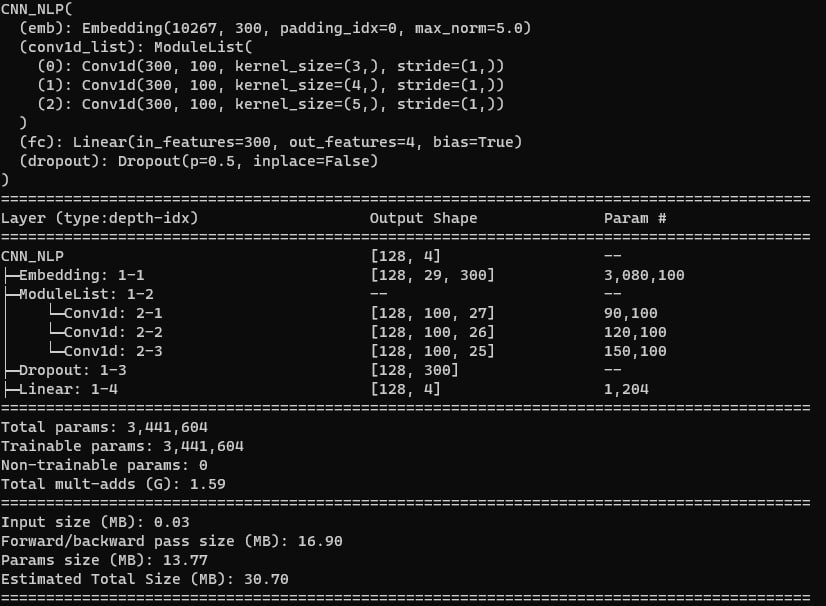


In [ ]:
class CNN_NLP(nn.Module):
    """An 1D Convulational Neural Network for Sentence Classification.
    Adapted from: https://www.kaggle.com/code/williamlwcliu/cnn-text-classification-pytorch"""
    def __init__(self,
                 pretrained_embedding=None,
                 freeze_embedding=False,
                 vocab_size=None,
                 embed_dim=100,
                 filter_sizes=[3, 4, 5],
                 num_filters=[100, 100, 100],
                 num_classes=4,
                 dropout=0.5):
        """
        The constructor for CNN_NLP class.

        Args:
            pretrained_embedding (torch.Tensor): Pretrained embeddings with
                shape (vocab_size, embed_dim)
            freeze_embedding (bool): Set to False to fine-tune pretraiend
                vectors. Default: False
            vocab_size (int): Need to be specified when not pretrained word
                embeddings are not used.
            embed_dim (int): Dimension of word vectors. Need to be specified
                when pretrained word embeddings are not used. Default: 300
            filter_sizes (List[int]): List of filter sizes. Default: [3, 4, 5]
            num_filters (List[int]): List of number of filters, has the same
                length as `filter_sizes`. Default: [100, 100, 100]
            n_classes (int): Number of classes. Default: 2
            dropout (float): Dropout rate. Default: 0.5
        """

        super(CNN_NLP, self).__init__()
        # Embedding layer
        if pretrained_embedding is not None:
            pretrained_embeddings = torch.from_numpy(pretrained_embedding).float()
            self.emb = nn.Embedding(embedding_dim=embed_dim,
                                    num_embeddings=vocab_size,
                                    padding_idx=0,
                                    _weight=pretrained_embeddings)
        else:
            self.embed_dim = embed_dim
            self.emb = nn.Embedding(num_embeddings=vocab_size,
                                          embedding_dim=embed_dim,
                                          padding_idx=0,
                                          max_norm=5.0)
        # Conv Network
        self.conv1d_list = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim,
                      out_channels=num_filters[i],
                      kernel_size=filter_sizes[i])
            for i in range(len(filter_sizes))
        ])
        # Fully-connected layer and Dropout
        self.fc = nn.Linear(np.sum(num_filters), num_classes)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, input_ids):
        """Perform a forward pass through the network.

        Args:
            input_ids (torch.Tensor): A tensor of token ids with shape
                (batch_size, max_sent_length)

        Returns:
            logits (torch.Tensor): Output logits with shape (batch_size,
                n_classes)
        """

        # Get embeddings from `input_ids`. Output shape: (b, max_len, embed_dim)
        x_embed = self.emb(input_ids).float()

        # Permute `x_embed` to match input shape requirement of `nn.Conv1d`.
        # Output shape: (b, embed_dim, max_len)
        x_reshaped = x_embed.permute(0, 2, 1)

        # Apply CNN and ReLU. Output shape: (b, num_filters[i], L_out)
        x_conv_list = [F.relu(conv1d(x_reshaped)) for conv1d in self.conv1d_list]

        # Max pooling. Output shape: (b, num_filters[i], 1)
        x_pool_list = [F.max_pool1d(x_conv, kernel_size=x_conv.shape[2])
            for x_conv in x_conv_list]

        # Concatenate x_pool_list to feed the fully connected layer.
        # Output shape: (b, sum(num_filters))
        x_fc = torch.cat([x_pool.squeeze(dim=2) for x_pool in x_pool_list],
                         dim=1)

        # Compute logits. Output shape: (b, n_classes)
        logits = self.fc(self.dropout(x_fc))

        return logits

## Utils

Ahora vamos a cargar el resto de funciones que vamos a usar durante el entrenamiento de los modelos.

In [ ]:
from gensim.models import KeyedVectors
from huggingface_hub import hf_hub_download


def set_seed_everywhere(seed, cuda):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed_all(seed)


def download_embedding_file(repo_id, filename, local_dir ):
    if not os.path.exists(local_dir + filename):
        print("Descargando los word embeddings")
        hf_hub_download(repo_id=repo_id, filename=filename, local_dir=local_dir)
    else:
        print("El fichero de embeddings ya está descargado.")


def get_embedding_file(embeddings_folder, filename):
    model = KeyedVectors.load_word2vec_format(embeddings_folder + filename)
    return model


def make_embedding_matrix( local_dir, filename, words_idx_to_token, emb_dim):
    embeddings_gensim = get_embedding_file(local_dir, filename)
    final_embeddings = np.zeros((len(words_idx_to_token), emb_dim))
    for idx in sorted(words_idx_to_token):
        if words_idx_to_token[idx] in embeddings_gensim.key_to_index:
            final_embeddings[idx, :] = embeddings_gensim[words_idx_to_token[idx]]
        else:
            embedding_i = torch.ones(1, emb_dim)
            torch.nn.init.xavier_uniform_(embedding_i)
            final_embeddings[idx, :] = embedding_i
            print(f"Word {words_idx_to_token[idx]} not in model")

    return final_embeddings

## Configuración de los modelos

In [ ]:
    args = Namespace(
        # Data and Path hyper parameters
        news_csv="/content/drive/MyDrive/Cursos impartidos/NLP/Corpus/ag_news/news_with_splits.csv",
        vectorizer_file="vectorizer.json",
        model_state_file="model_storage/model.pth",
        save_dir="model_storage/document_classification",
        # Model hyper parameters
        use_cnn_nlp = True,
        use_emb=False,
        repo_id = "Word2vec/wikipedia2vec_enwiki_20180420_300d", #Alternativa: "Word2vec/wikipedia2vec_enwiki_20180420_300d"
        filename = "enwiki_20180420_300d.txt", #Alternativa: "enwiki_20180420_300d.txt"
        local_dir="/content/drive/MyDrive/Cursos impartidos/NLP/Embeddings/",
        embedding_size=300, #Depende del modelo de word embeddings que usemos. Alternativa: 300
        hidden_dim=100,
        num_channels=100, #AKA number of filters
        # Training hyper parameter
        seed=1337,
        learning_rate=0.001,
        dropout_p=0.1,
        batch_size=128,
        num_epochs=100,
        early_stopping_criteria=5,
        # Runtime option
        cuda=True,
        catch_keyboard_interrupt=True,
    )

## Training loop

**Ejercicio 3**: Una vez definidas todas las clases y funciones necesarias para crear los diferentes modelos, vamos probar la siguientes configuraciones:


*   Sin embeddings y con NewsClassifier.
*   Con embeddings (100 dimensiones) y con NewsClassifier.
*   Sin embeddings y con CNN_NLP.
*   Con embeddings (100 dimensiones) y con CNN_NLP.

**Ejercicio 3b**:
*   Cambia el cut-off del número mínimo de repeticiones para que una palabra forma parte del vocabulario y pruebalo con el mejor modelo.
*   Usa un Word2Vec de 300 dimensiones con el mejor modelo.





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Check CUDA
if not torch.cuda.is_available():
    args.cuda = False

args.device = torch.device("cuda" if args.cuda else "cpu")
print("Using CUDA: {}".format(args.cuda))

# Set seed for reproducibility
set_seed_everywhere(args.seed, args.cuda)

# create dataset and vectorizer
dataset = NewsDataset.load_dataset_and_make_vectorizer(args.news_csv)
dataset.save_vectorizer(args.vectorizer_file)
vectorizer = dataset.get_vectorizer()

if args.use_emb:
    review_vocab = dataset.get_vectorizer().title_vocab
    print(review_vocab)
    repo_id = args.repo_id
    filename = args.filename
    local_dir = args.local_dir
    download_embedding_file(repo_id, filename, local_dir)
    embeddings = make_embedding_matrix(local_dir, filename, review_vocab._idx_to_token, args.embedding_size)
    print("Using pre-trained embeddings")
else:
    print("Not using pre-trained embeddings")
    embeddings = None

In [ ]:
if not args.use_cnn_nlp:
    classifier = NewsClassifier(embedding_size=args.embedding_size,
                                num_embeddings=len(vectorizer.title_vocab),
                                num_channels=args.num_channels, #Not channels as in Keras.
                                hidden_dim=args.hidden_dim,
                                num_classes=len(vectorizer.category_vocab),
                                dropout_p=args.dropout_p,
                                pretrained_embeddings=embeddings,
                                padding_idx=0)
else:
    classifier = CNN_NLP(pretrained_embedding=embeddings,
                        freeze_embedding=False,
                        vocab_size=len(vectorizer.title_vocab),
                        embed_dim=args.embedding_size,
                        num_classes=len(vectorizer.category_vocab))

In [ ]:
classifier = classifier.to(args.device)
dataset.class_weights = dataset.class_weights.to(args.device)

loss_func = nn.CrossEntropyLoss(dataset.class_weights)
optimizer = optim.Adam(classifier.parameters(), lr=args.learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer,
                                           mode='min', factor=0.5,
                                           patience=1)

train_state = make_train_state(args)

summary_shown = False

try:
    for epoch_index in range(args.num_epochs):
        train_state['epoch_index'] = epoch_index

        # Iterate over training dataset

        # setup: batch generator, set loss and acc to 0, set train mode on

        dataset.set_split('train')
        batch_generator = generate_batches(dataset,
                                           batch_size=args.batch_size,
                                           device=args.device)
        running_loss = 0.0
        running_acc = 0.0
        classifier.train()

        for batch_index, batch_dict in enumerate(batch_generator):
            if not summary_shown:
                print(summary(classifier, input_data=[batch_dict['x_data']]))
                summary_shown = True
            # the training routine is these 5 steps:

            # --------------------------------------
            # step 1. zero the gradients
            optimizer.zero_grad()

            # step 2. compute the output
            y_pred = classifier(batch_dict['x_data'])

            # step 3. compute the loss
            loss = loss_func(y_pred, batch_dict['y_target'])
            loss_t = loss.item()
            running_loss += (loss_t - running_loss) / (batch_index + 1)

            # step 4. use loss to produce gradients
            loss.backward()

            # step 5. use optimizer to take gradient step
            optimizer.step()
            # -----------------------------------------
            # compute the accuracy
            acc_t = compute_accuracy(y_pred, batch_dict['y_target'])
            running_acc += (acc_t - running_acc) / (batch_index + 1)


        train_state['train_loss'].append(running_loss)
        train_state['train_acc'].append(running_acc)

        # Iterate over val dataset

        # setup: batch generator, set loss and acc to 0; set eval mode on
        dataset.set_split('val')
        batch_generator = generate_batches(dataset,
                                           batch_size=args.batch_size,
                                           device=args.device)
        running_loss = 0.
        running_acc = 0.
        classifier.eval()

        for batch_index, batch_dict in enumerate(batch_generator):

            # compute the output
            y_pred =  classifier(batch_dict['x_data'])

            # step 3. compute the loss
            loss = loss_func(y_pred, batch_dict['y_target'])
            loss_t = loss.item()
            running_loss += (loss_t - running_loss) / (batch_index + 1)

            # compute the accuracy
            acc_t = compute_accuracy(y_pred, batch_dict['y_target'])
            running_acc += (acc_t - running_acc) / (batch_index + 1)


        train_state['val_loss'].append(running_loss)
        train_state['val_acc'].append(running_acc)
        print(f"In epoch {epoch_index} el vall_acc es {running_acc} y el val_loss es {running_loss}" )

        train_state = update_train_state(args=args, model=classifier,
                                         train_state=train_state)

        scheduler.step(train_state['val_loss'][-1])
        print(f"Early stopping state is {train_state['early_stopping_step']}")
        if train_state['stop_early']:
            break

except KeyboardInterrupt:
    print("Exiting loop")


**Ejercicio 4**: usando el mejor modelo de cada configuración calcula el *test_loss* y *test_accuracy*.

In [ ]:
# compute the loss & accuracy on the test set using the best available model

classifier.load_state_dict(torch.load(train_state['model_filename']))

classifier = classifier.to(args.device)
dataset.class_weights = dataset.class_weights.to(args.device)
loss_func = nn.CrossEntropyLoss(dataset.class_weights)

dataset.set_split('test')
batch_generator = generate_batches(dataset,
                                   batch_size=args.batch_size,
                                   device=args.device)
running_loss = 0.
running_acc = 0.
classifier.eval()

for batch_index, batch_dict in enumerate(batch_generator):
    # compute the output
    y_pred =  classifier(batch_dict['x_data'])

    # compute the loss
    loss = loss_func(y_pred, batch_dict['y_target'])
    loss_t = loss.item()
    running_loss += (loss_t - running_loss) / (batch_index + 1)

    # compute the accuracy
    acc_t = compute_accuracy(y_pred, batch_dict['y_target'])
    running_acc += (acc_t - running_acc) / (batch_index + 1)

train_state['test_loss'] = running_loss
train_state['test_acc'] = running_acc
print("Test loss: {};".format(train_state['test_loss']))
print("Test Accuracy: {}".format(train_state['test_acc']))